# ☕ Cafe Sales Data Cleaning Project
### Tools: Python, Pandas, NumPy, Matplotlib, Seaborn
### Dataset: 10,000 dirty cafe transactions

## 🎯 Project Goal
Practice data cleaning techniques on an intentionally 
messy dataset. This project focuses primarily on **cleaning and 
preprocessing** rather than deep analysis — reflecting the reality 
that data cleaning accounts for 60-70% of a data analyst's work.

---

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.random.seed(22)
print("READY TO SLEEP")
cafe_sa = pd.read_csv("dirty_cafe_sales.csv", index_col= False)
cafe_sa.head(10)

READY TO SLEEP


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 🔍 Initial Data Exploration

First step: understand what we're working with before touching anything.

- Dataset: 10,000 rows × 8 columns
- Columns: Transaction ID, Item, Quantity, Price Per Unit, 
  Total Spent, Payment Method, Location, Transaction Date

**Hidden dirty data found:**  
`isnull().sum()` showed zero missing values — but looping through 
`.value_counts()` revealed `"ERROR"` and `"UNKNOWN"` strings hiding 
in multiple columns, which pandas doesn't recognize as NaN.

| Column | ERROR count | UNKNOWN count |
|--------|-------------|---------------|
| Item | 292 | 344 |
| Quantity | 170 | 171 |
| Price Per Unit | 190 | 164 |
| Total Spent | 164 | 165 |
| Payment Method | 306 | 293 |

**Fix:** Replaced all `"ERROR"` and `"UNKNOWN"` with `np.nan`

In [86]:
cafe_sa.info()
# cafe_sa.describe()
cafe_sa.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


(10000, 8)

In [87]:
#Find all missing values
for col in cafe_sa.columns:
    print(col, cafe_sa[col].value_counts())

Transaction ID Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
              ..
TXN_7672686    1
TXN_9659401    1
TXN_5255387    1
TXN_7695629    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64
Item Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64
Quantity Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64
Price Per Unit Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64
Total Spent Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0   

In [88]:
#Replace all 'UNKOWN' and 'ERROR' as Nan
cafe_sa = cafe_sa.replace(['UNKNOWN','ERROR'], np.nan)

## 🔧 Data Type Conversion

All columns loaded as `str` (object) dtype — needed fixing:

- `Quantity`, `Price Per Unit`, `Total Spent` → converted to `float`
- `Transaction Date` → converted using `pd.to_datetime()`

Without this step, math operations (filling missing values 
by calculation) would fail entirely.

In [ ]:
cafe_sa.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [90]:
# CHANGE THE DATA TYPES
flt_cat = ['Quantity','Price Per Unit','Total Spent']
cafe_sa[flt_cat] = cafe_sa[flt_cat].astype(float)
cafe_sa['Transaction Date'] = pd.to_datetime(cafe_sa['Transaction Date'])
cafe_sa.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [91]:
# NaN
missing_value_nan = cafe_sa.isnull().sum()
total_missing = missing_value_nan.sum()
total_cells = np.prod(cafe_sa.shape)
percent_miss = (total_missing/total_cells) * 100
print('Percent of Missing Data is',percent_miss.round(2),'%')
missing_value_nan

Percent of Missing Data is 12.6 %


Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [92]:
cafe_sa.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


## 🧮 Math Relationship

Key insight: **Total Spent = Price Per Unit × Quantity**

This means if any two of the three values are known, 
the third can be calculated — no guessing needed.

Three conditions handled:
1. **Price Per Unit missing** → Total Spent ÷ Quantity
2. **Quantity missing** → Total Spent ÷ Price Per Unit  
3. **Total Spent missing** → Quantity × Price Per Unit

This approach recovers real data rather than filling 
with potentially wrong estimates like mean or median.

In [93]:
#Fill the  Quantity or Price Per Unit or Total Spent
# >>> As we knew that Total Spent = Price Per Unit * Quantity <<<
# if we have either two of these variable, we can fill the NaN

# First Coditions : know Quantity or Total Spent
price_unit_filldata = (cafe_sa['Price Per Unit'].isnull()) & (cafe_sa[['Quantity','Total Spent']].notna().all(axis=1))
cafe_sa[price_unit_filldata]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
56,TXN_3578141,Cake,5.0,NaN,15.0,NaN,Takeaway,2023-06-27
68,TXN_8427104,Salad,2.0,NaN,10.0,NaN,In-store,2023-10-27
85,TXN_8035512,Tea,3.0,NaN,4.5,Cash,NaN,2023-10-29
104,TXN_7447872,Juice,2.0,NaN,6.0,NaN,NaN,NaT
118,TXN_4633784,NaN,5.0,NaN,15.0,NaN,In-store,2023-02-06
...,...,...,...,...,...,...,...,...
9924,TXN_5981429,Juice,2.0,NaN,6.0,Digital Wallet,NaN,2023-12-24
9926,TXN_2464706,Cake,4.0,NaN,12.0,Digital Wallet,Takeaway,2023-11-09
9961,TXN_2153100,Tea,2.0,NaN,3.0,Cash,NaN,2023-12-29
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02


In [94]:
# Filling up the first condition:
cafe_sa.loc[price_unit_filldata,'Price Per Unit'] = (cafe_sa.loc[price_unit_filldata,'Total Spent']/
                                                    cafe_sa.loc[price_unit_filldata,'Quantity'])
# cafe_sa.loc[price_unit_filldata,'Price Per Unit'] #check its alr filled

In [95]:
# Second Coditions : know Price Per Unit or Total Spent
quantity_filldata = (cafe_sa['Quantity'].isnull()) & (cafe_sa[['Price Per Unit','Total Spent']].notna().all(axis=1))
cafe_sa[quantity_filldata]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,NaN,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,NaN,1.0,2.0,Credit Card,Takeaway,2023-03-19
57,TXN_2080895,Cake,NaN,3.0,3.0,Digital Wallet,In-store,2023-04-19
66,TXN_8501819,Juice,NaN,3.0,6.0,Cash,NaN,2023-03-30
117,TXN_2148617,Juice,NaN,3.0,9.0,Digital Wallet,NaN,2023-01-10
...,...,...,...,...,...,...,...,...
9932,TXN_8502079,Tea,NaN,1.5,3.0,Cash,NaN,2023-04-20
9935,TXN_9778251,Tea,NaN,1.5,6.0,NaN,Takeaway,2023-11-09
9944,TXN_7495283,Cake,NaN,3.0,15.0,Credit Card,Takeaway,2023-04-14
9957,TXN_6487003,Coffee,NaN,2.0,8.0,Credit Card,Takeaway,2023-11-15


In [96]:
# Filling up the second condition:
cafe_sa.loc[quantity_filldata,'Quantity'] = (cafe_sa.loc[quantity_filldata,'Total Spent']/
                                                    cafe_sa.loc[quantity_filldata,'Price Per Unit'])
# cafe_sa.loc[quantity_filldata,'Quantity'] #check its alr filled

In [97]:
# Third Coditions : know Price Per Unit or Quantity
ttspent_filldata = (cafe_sa['Total Spent'].isnull()) & (cafe_sa[['Price Per Unit','Quantity']].notna().all(axis=1))
cafe_sa[ttspent_filldata]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
25,TXN_7958992,Smoothie,3.0,4.0,NaN,NaN,NaN,2023-12-13
31,TXN_8927252,NaN,2.0,1.0,NaN,Credit Card,NaN,2023-11-06
42,TXN_6650263,Tea,2.0,1.5,NaN,NaN,Takeaway,2023-01-10
94,TXN_6289610,Juice,3.0,3.0,NaN,Cash,Takeaway,2023-08-07
...,...,...,...,...,...,...,...,...
9890,TXN_2749289,Smoothie,2.0,4.0,NaN,Digital Wallet,Takeaway,2023-05-05
9954,TXN_1191659,Coffee,4.0,2.0,NaN,Credit Card,In-store,2023-11-21
9977,TXN_5548914,Juice,2.0,3.0,NaN,Digital Wallet,In-store,2023-11-04
9988,TXN_9594133,Cake,5.0,3.0,NaN,NaN,NaN,NaT


In [98]:
# Filling up the third condition:
cafe_sa.loc[ttspent_filldata,'Total Spent'] = (cafe_sa.loc[ttspent_filldata,'Quantity']*
                                                    cafe_sa.loc[ttspent_filldata,'Price Per Unit'])
# cafe_sa.loc[ttspent_filldata,'Total Spent'] #check its alr filled

In [99]:
# Transaction ID         0
# Item                 969
# Quantity             479 < must be changed
# Price Per Unit       533 <
# Total Spent          502 <
# Payment Method      3178
# Location            3961
# Transaction Date     460
cafe_sa.isnull().sum()

Transaction ID         0
Item                 969
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

## 🍽️ Item & Price Per Unit Filling

Each cafe item has a consistent fixed price — this relationship 
can be used bidirectionally:

- **Known Price Per Unit → fill missing Item** (reverse mapping)
- **Known Item → fill missing Price Per Unit** (forward mapping)

⚠️ Limitation: Cake/Juice both cost $3.00 and Sandwich/Smoothie 
both cost $4.00 — ambiguous prices cannot be mapped to a specific item.
Remaining 477 Item NaNs kept intentionally (see decision below).

In [100]:
# As we knew that ONE ITEM must have the consistent price:
item_prices = cafe_sa.groupby('Item')['Price Per Unit'].first()
item_prices

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64

In [101]:
# Cake        3.0
# Coffee      2.0 >>> Unique
# Cookie      1.0 >>> Unique
# Juice       3.0
# Salad       5.0 >>> Unique
# Sandwich    4.0
# Smoothie    4.0
# Tea         1.5 >>> Unique

# Prices Dictionary
items = {"Coffee": 2.0, "Cookie": 1.0,
         "Salad": 5.0, "Tea": 1.5
         }

all_items = {
    "Coffee": 2.0, "Cake": 3.0, "Cookie": 1.0,
    "Salad": 5.0, "Smoothie": 4.0, "Sandwich": 4.0,
    "Juice": 3.0, "Tea": 1.5
}
# Fill missing Items using Price Per Unit
reverse_items = {price: item for item, price in items.items()}
cafe_sa['Item'] = cafe_sa['Item'].fillna(cafe_sa['Price Per Unit'].map(reverse_items))

# Fill missing Price Per Unit using Item
cafe_sa['Price Per Unit'] = cafe_sa['Price Per Unit'].fillna(cafe_sa['Item'].map(all_items))

cafe_sa.isnull().sum()

Transaction ID         0
Item                 480
Quantity              38
Price Per Unit         6
Total Spent           40
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [102]:
# AS we got all news Price Per Unit
# : we can Recalculate Total Spent and Quantity as well
# Filling Total Spent
T_filldata = ((cafe_sa['Total Spent'].isnull()) & (cafe_sa[['Price Per Unit','Quantity']].notna().all(axis=1)))
cafe_sa[T_filldata]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
65,TXN_4987129,Sandwich,3.0,4.0,NaN,NaN,In-store,2023-10-20
1674,TXN_9367492,Tea,2.0,1.5,NaN,Cash,In-store,2023-06-19
2229,TXN_8498613,Sandwich,2.0,4.0,NaN,NaN,NaN,2023-11-08
2585,TXN_1259340,Tea,3.0,1.5,NaN,Digital Wallet,NaN,2023-02-24
3162,TXN_3577949,Cake,3.0,3.0,NaN,NaN,Takeaway,2023-04-25
3598,TXN_2857444,Smoothie,1.0,4.0,NaN,Cash,Takeaway,2023-05-10
3673,TXN_6500126,Smoothie,2.0,4.0,NaN,NaN,NaN,NaT
4021,TXN_6424202,Cookie,2.0,1.0,NaN,Credit Card,In-store,2023-11-20
7035,TXN_8872984,Salad,5.0,5.0,NaN,Credit Card,In-store,2023-08-23
7230,TXN_5118799,Cookie,2.0,1.0,NaN,Cash,Takeaway,2023-04-23


In [103]:
# Filling up Total Spent:
cafe_sa.loc[T_filldata,'Total Spent'] = (cafe_sa.loc[T_filldata,'Quantity']*
                                                    cafe_sa.loc[T_filldata,'Price Per Unit'])
# cafe_sa.loc[T_filldata,'Total Spent'] #check its alr filled

In [104]:
Q_filldata = (cafe_sa['Quantity'].isnull()) & (cafe_sa[['Price Per Unit','Total Spent']].notna().all(axis=1))
cafe_sa[Q_filldata]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
629,TXN_9289174,Cake,NaN,3.0,12.0,Digital Wallet,In-store,2023-12-30
912,TXN_1575608,Sandwich,NaN,4.0,20.0,NaN,Takeaway,2023-01-05
1008,TXN_7225428,Tea,NaN,1.5,3.0,Credit Card,Takeaway,2023-03-07
1436,TXN_7590801,Tea,NaN,1.5,6.0,Cash,Takeaway,NaT
1482,TXN_3593060,Smoothie,NaN,4.0,16.0,Cash,NaN,2023-03-05
2330,TXN_3849488,Salad,NaN,5.0,5.0,NaN,In-store,2023-03-01
3635,TXN_6177081,Cookie,NaN,1.0,1.0,Cash,NaN,2023-07-26
5639,TXN_6206792,Tea,NaN,1.5,6.0,Credit Card,NaN,2023-10-13
5845,TXN_8388462,Smoothie,NaN,4.0,8.0,NaN,Takeaway,2023-08-19
6225,TXN_6859249,Cookie,NaN,1.0,2.0,NaN,NaN,NaT


In [105]:
# Filling up Quantity:
cafe_sa.loc[Q_filldata,'Quantity'] = (cafe_sa.loc[Q_filldata,'Total Spent']/
                                                    cafe_sa.loc[Q_filldata,'Price Per Unit'])
# cafe_sa.loc[Q_filldata,'Quantity'] #check its alr filled

In [106]:
# Item                 480
# Quantity              38 <
# Price Per Unit         6
# Total Spent           40 <
# Payment Method      3178
# Location            3961
# Transaction Date     460
cafe_sa.isnull().sum()

Transaction ID         0
Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [107]:
# Recheck futher more what we can do
no_tts = cafe_sa[cafe_sa['Total Spent'].isnull()]
no_tts

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
641,TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17
738,TXN_8696094,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-05-14
1761,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
2796,TXN_9188692,Cake,NaN,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,NaN,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3224,TXN_6297232,Coffee,NaN,2.0,NaN,NaN,NaN,2023-04-07
3401,TXN_3251829,Tea,NaN,1.5,NaN,Digital Wallet,In-store,2023-07-25


## 📋 Cleaning Decisions & Reasoning

| Column | Decision | Reason |
|--------|----------|--------|
| Item (477 NaN) | Keep as NaN | Revenue data still valid — dropping would undercount total revenue |
| Total Spent (remaining) | Drop rows | No revenue = no analytical value |
| Payment Method (31% missing) | Fill → "Unknown" | Too high % to guess reliably — mode fill would artificially inflate one category |
| Location (39% missing) | Fill → "Unknown" | Same reasoning as Payment Method |
| Transaction Date | Keep NaN | Excluded only for time-based analysis using `.dropna(subset=['Transaction Date'])` |

In [108]:
# Decision: Keep remaining NaN 'Item' rows
# Reason: Revenue data (Price Per Unit, Quantity, Total Spent) 
# is still valid and dropping rows would undercount total cafe revenue.
# These rows will be excluded only from item-specific analysis.
cafe_sa= cafe_sa.dropna(subset=['Total Spent'])
cafe_sa.isnull().sum()

Transaction ID         0
Item                 477
Quantity               3
Price Per Unit         3
Total Spent            0
Payment Method      3169
Location            3953
Transaction Date     460
dtype: int64

In [109]:
# Decision: Keep as 'Unknown'
# Reason : Dropna might impact Revenue data 
cafe_sa['Payment Method'] = cafe_sa['Payment Method'].fillna('Unknown')
cafe_sa['Location'] = cafe_sa['Location'].fillna('Unknown')
cafe_sa.isnull().sum()

Transaction ID        0
Item                477
Quantity              3
Price Per Unit        3
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [110]:
# Parsed Date
cafe_sa['Day'] = cafe_sa['Transaction Date'].dt.day
cafe_sa['Month'] = cafe_sa['Transaction Date'].dt.month
cafe_sa['Year'] = cafe_sa['Transaction Date'].dt.year

## 📊 Post-Cleaning Analysis

After cleaning, three basic questions explored:

### Best Selling Item (by Revenue)
Salad leads with ~$19,000 total revenue — highest priced item 
($5.00) combined with consistent demand = top revenue generator.
Coffee wins by quantity but not revenue — classic price/volume tradeoff.

### Revenue by Month
Relatively stable throughout the year (~$6,700–$7,350 monthly).
February shows the lowest revenue — likely due to being the shortest month.
No strong seasonal pattern detected.

### Average Transaction Value
Average spend per transaction: ~$8.91

### Payment Method & Location
⚠️ **Important limitation:** 31% of Payment Method and 39% of 
Location data is missing. Charts shown both with and without 
"Unknown" category for transparency.

Among known transactions:
- Payment methods are evenly split — no dominant preference
- In-store and Takeaway revenue nearly identical — cafe serves 
  both segments equally

In [111]:
# After cleaning
# What's the best-selling product?
best_sale = cafe_sa.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
best_sale

Item
Salad       19095.0
Sandwich    13716.0
Smoothie    13344.0
Juice       10515.0
Cake        10404.0
Coffee       7808.0
Tea          5475.0
Cookie       3598.0
Name: Total Spent, dtype: float64

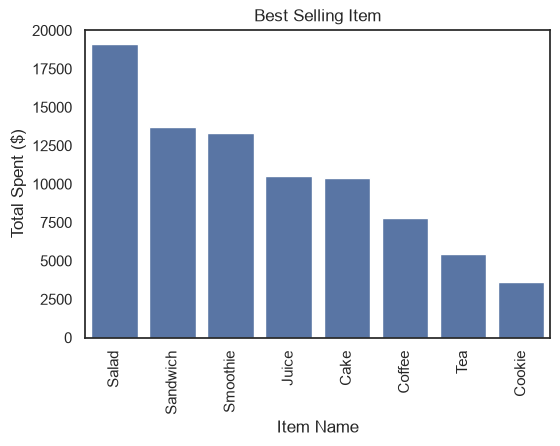

In [112]:
sns.set_theme(style='white')
plt.figure(figsize=(6, 4))
sns.barplot(x= best_sale.index, y= best_sale.values,order= best_sale.index)
plt.title('Best Selling Item')
plt.xlabel('Item Name')
plt.ylabel('Total Spent ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation = 90)
plt.show()

In [113]:
# Which month had the highest revenue?
high_rev_byM = cafe_sa.groupby('Month')['Total Spent'].sum().sort_values(ascending=False)
high_rev_byM

Month
6.0     7353.0
10.0    7314.0
1.0     7254.0
3.0     7216.0
4.0     7179.0
12.0    7177.0
8.0     7112.5
11.0    6967.0
5.0     6957.5
7.0     6877.5
9.0     6871.0
2.0     6644.0
Name: Total Spent, dtype: float64

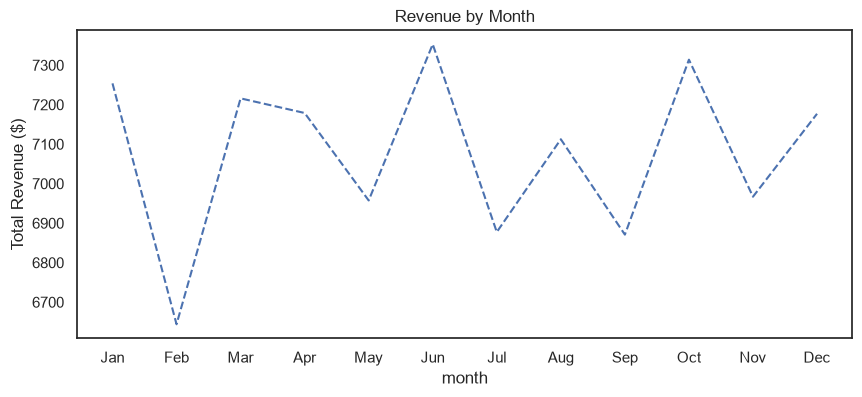

In [114]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 4))
sns.lineplot(x= high_rev_byM.index, y= high_rev_byM.values, linestyle ='--')
plt.title('Revenue by Month')
plt.xlabel('month')
plt.ylabel('Total Revenue ($)')
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], ['Jan', 'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

In [115]:
# What's the average transaction value?
avg_tran =  cafe_sa['Total Spent'].mean()
avg_tran

np.float64(8.930139320437005)

In [116]:
# The top 5 items by total quantity sold.
top_byQ = cafe_sa.groupby('Item')['Quantity'].sum().sort_values(ascending=False)
top_byQ

Item
Coffee      3904.0
Salad       3819.0
Tea         3650.0
Cookie      3598.0
Juice       3505.0
Cake        3468.0
Sandwich    3429.0
Smoothie    3336.0
Name: Quantity, dtype: float64

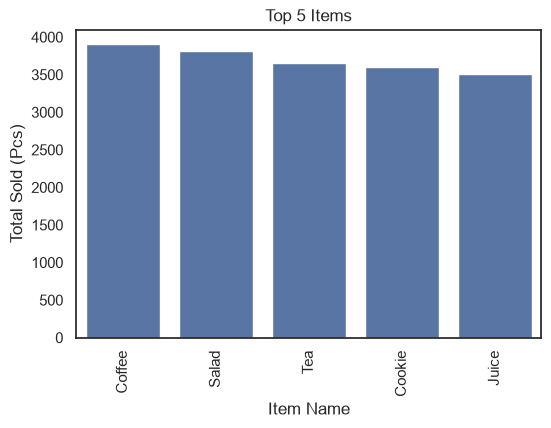

In [117]:
sns.set_theme(style='white')
plt.figure(figsize=(6, 4))
sns.barplot(x= top_byQ.index, y= top_byQ.values,order= top_byQ.index)
plt.xlim(-0.5,4.5)
plt.title('Top 5 Items')
plt.xlabel('Item Name')
plt.ylabel('Total Sold (Pcs)')
plt.xticks(rotation = 90)
plt.show()

In [118]:
# Total revenue by payment method
pay_byRev = cafe_sa.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False).reset_index()
pay_byRev

,Payment Method,Total Spent
0,Unknown,27813.5
1,Credit Card,20466.0
2,Digital Wallet,20414.0
3,Cash,20402.5


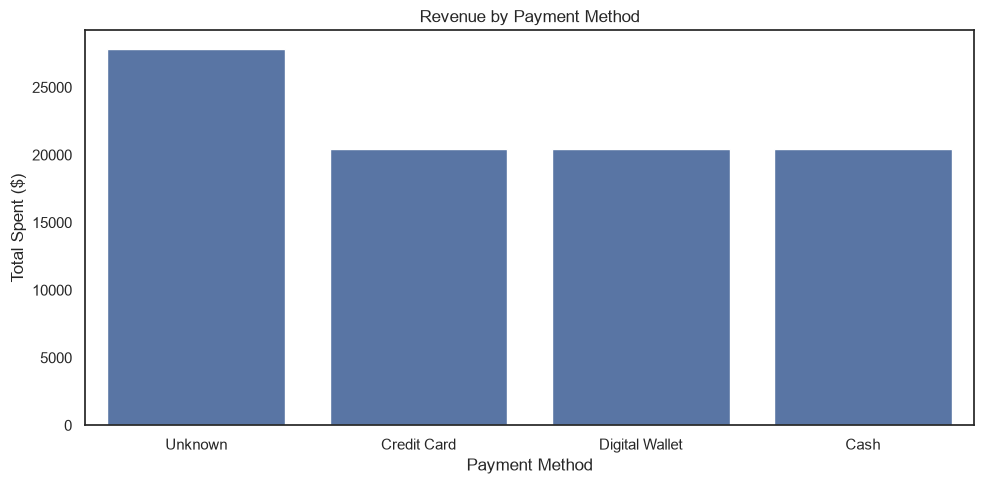

In [119]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.barplot(data=pay_byRev, x='Payment Method', y='Total Spent')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

In [120]:
# Total Revenue by Location
loc_byRev = cafe_sa.groupby('Location')['Total Spent'].sum().sort_values(ascending=False).reset_index()
loc_byRev

,Location,Total Spent
0,Unknown,35369.5
1,In-store,27174.0
2,Takeaway,26552.5


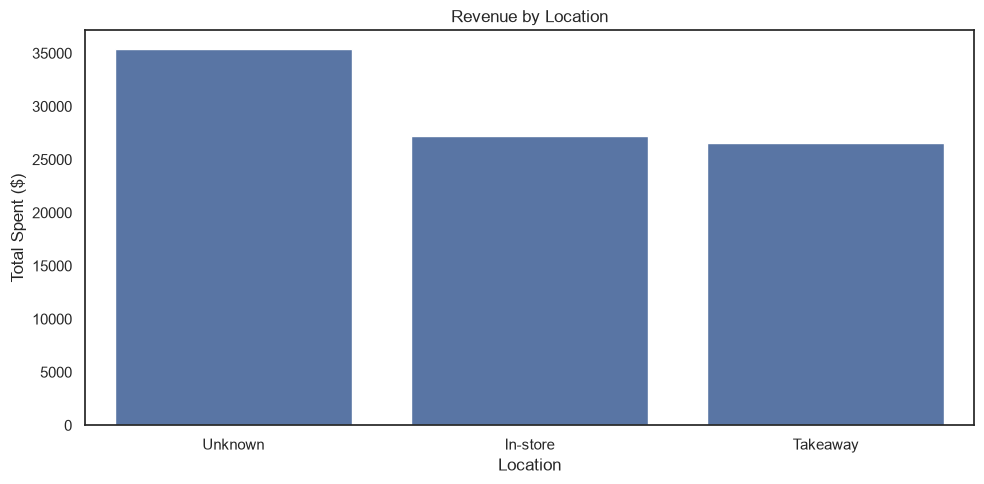

In [121]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.barplot(data=loc_byRev, x='Location', y='Total Spent')
plt.title('Revenue by Location')
plt.xlabel('Location')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

## 🔍 Outlier Detection

Applied 3 standard deviation rule to Total Spent:
- Mean: ~$8.91
- Upper Bound: ~$26.73
- Lower Bound: negative (impossible for transactions)

**Finding:** No outliers detected ✅  
This makes sense — cafe spending is naturally bounded by 
menu prices ($1.00–$5.00) and maximum quantity (5 items).
Confirms revenue data is internally consistent post-cleaning.

In [122]:
std_tts = cafe_sa['Total Spent'].std()
mean_tts = cafe_sa['Total Spent'].mean()
criteria = std_tts * 3

lower_bound = mean_tts - criteria
upper_bound = mean_tts + criteria

outliers = cafe_sa[(cafe_sa['Total Spent'] < lower_bound) | (cafe_sa['Total Spent'] > upper_bound)]
print(outliers['Total Spent'].sort_values(ascending=False))

Series([], Name: Total Spent, dtype: float64)


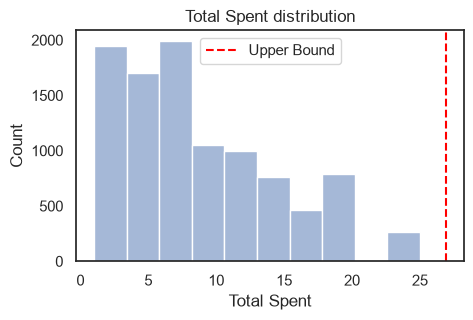

In [123]:
# Total Spent distribution

sns.set_theme(style='white')
plt.figure(figsize=(5, 3))

plt.axvline(x=upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.legend()

sns.histplot(data = cafe_sa_copy, x='Total Spent',bins=10,alpha = 0.5)
plt.title('Total Spent distribution')
plt.show()

## 🎯 Key Takeaways

**Cleaning lessons from this project:**
1. Missing values aren't always `NaN` — always check `.value_counts()` 
   for hidden dirty data like `"ERROR"` and `"UNKNOWN"`
2. Math relationships between columns enable smart imputation 
   without guessing
3. High missing % (30-40%) should be flagged as "Unknown" 
   rather than filled with mode — honesty over false precision
4. Not all NaNs should be dropped — context determines the right decision

**Data quality after cleaning:**
- Started with: 10,000 rows, 0 detected NaN (hidden dirty data)
- Ended with: ~9,600 rows, all revenue columns complete
- Total Spent: fully clean ✅
- Item: 477 NaN intentionally kept ✅